#### TypedDict

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypeDictState(TypedDict):
    name :str
    game: Literal["cricket", "badminton"]


In [9]:
import random

def play_game(state:TypeDictState):
    print("----Play Game node is called----")
    return {"name":state['name'] + " wants to play "}

def cricket(state:TypeDictState):
    print("----Cricket Node has been called ----")
    return{"name":state['name'] + "cricket", "game":"cricket"}

def badminton(state:TypeDictState):
    print("----Badminton Node has been called ----")
    return{"name":state['name'] + "badminton","game":"badminton"}

def decide_play(state:TypeDictState)->Literal["cricket","badminton"]:
    if random.random() < 0.5:
        return "cricket"
    return "badminton"

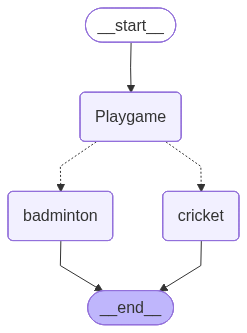

In [10]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START,END

builder = StateGraph(TypeDictState)
builder.add_node("Playgame", play_game)
builder.add_node("cricket", cricket)
builder.add_node("badminton",badminton)

builder.add_edge(START,"Playgame")
builder.add_conditional_edges("Playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
graph.invoke({"name":"Andy"})

----Play Game node is called----
----Cricket Node has been called ----


{'name': 'Andy wants to play cricket', 'game': 'cricket'}

#### DataClasses

In [12]:
from dataclasses import dataclass

@dataclass
class DataClassState:
    name:str
    game:Literal["badminton","cricket"]

In [13]:
def play_game(state:DataClassState):
    print("---Play Game node has been called--")
    return {"name":state.name + " want to play "}

def cricket(state:DataClassState):
    print("-- Cricket node has been called--")
    return {"name":state.name + " cricket","game":"cricket"}

def badminton(state:DataClassState):
    print("-- badminton node has been called--")
    return {"name":state.name + " badminton","game":"badminton"}

In [14]:
import random
def decide_play(state:DataClassState)->Literal["cricket","badminton"]:
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

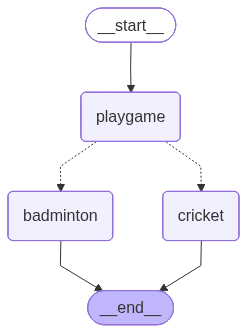

In [15]:
builder=StateGraph(DataClassState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## Flow of the graph

builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
graph.invoke(DataClassState(name="Andy",game="cricket"))

---Play Game node has been called--
-- Cricket node has been called--


{'name': 'Andy want to play  cricket', 'game': 'cricket'}